# 04 - Optimisation des hyperparamètres et du seuil métier

Objectifs :
- Optimiser les hyperparamètres des 4 modèles vus au notebook 03, en optimisant directement le coût métier (et pas l'AUC ou l'accuracy)
- Sélectionner le meilleur modèle
- Optimiser le **seuil de décision** pour minimiser le coût métier (le seuil 0.5 par défaut n'est jamais optimal sur un problème déséquilibré avec coûts asymétriques)

Tout est tracké dans MLflow (experiment dédié `P6_optimization`).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, make_scorer
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import shap

import mlflow
import mlflow.sklearn
from mlflow import MlflowClient

import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/processed/dataset.parquet'
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

In [2]:
# Chargement du dataset enrichi (sortie du notebook 02)
df = pd.read_parquet(DATA_PATH)
print(f"Shape : {df.shape}")

y = df['TARGET']
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])

# Nettoyage des noms de colonnes (LightGBM/XGBoost refusent les espaces/virgules/deux-points)
X.columns = [c.replace(' ', '_').replace(',', '_').replace(':', '_') for c in X.columns]

# Split train/test stratifié 80/20 (mêmes paramètres que notebook 03)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Shape : (307507, 797)
Train : (246005, 795), Test : (61502, 795)


## 2. Score métier (rappel)

Deux types d'erreurs avec un coût très inégal :
- **Crédit accordé à un client qui ne remboursera pas** = faux négatif (**FN**) : perte du capital prêté → **coût élevé**
- **Crédit refusé à un bon client** = faux positif (**FP**) : manque à gagner sur la marge d'intérêts → **coût faible**

Hypothèse du brief : **un FN coûte 10× plus qu'un FP**. On en fait un scorer sklearn pour l'utiliser dans le GridSearchCV.

In [3]:
def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost

# Scorer pour la CV : c'est un coût à minimiser, d'où greater_is_better=False
business_cost_scorer = make_scorer(business_cost, greater_is_better=False)

# Ratio pour scale_pos_weight (LightGBM / XGBoost)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

scale_pos_weight : 11.39


## 3. Setup MLflow

Nouvel experiment pour ne pas mélanger avec les runs baseline du notebook 03.

In [4]:
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('P6_optimization')

# Autolog pour les params et le modèle. log_models=False pour éviter le doublon avec le log_model manuel qu'on fera sur le modèle final.
mlflow.sklearn.autolog(log_models=False)

2026/05/16 16:47:14 INFO mlflow.tracking.fluent: Experiment with name 'P6_optimization' does not exist. Creating a new experiment.


## 4. GridSearchCV sur les 4 modèles

Pour chaque modèle on définit une grille d'hyperparamètres et on lance un GridSearchCV avec :
- Scoring = `business_cost` (à minimiser)
- StratifiedKFold 5 folds (préserve la répartition 92/8)
- `SimpleImputer(strategy='median')` comme au notebook 03
- `verbose=3` pour suivre l'avancement en temps réel

Chaque combinaison est logée automatiquement dans MLflow via autolog.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
imputer = SimpleImputer(strategy='median')

# Pipelines et grilles par modèle
# Note : on garde le scaler uniquement pour LogisticRegression (modèle linéaire). Les arbres (RF, LightGBM, XGBoost) sont insensibles à l'échelle.

grids = {
    'LogisticRegression': {
        'pipeline': Pipeline([
            ('imputer', imputer),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE,
            )),
        ]),
        'param_grid': {
            'model__C': [0.01, 0.1, 1, 10],
        },
    },
    'RandomForest': {
        'pipeline': Pipeline([
            ('imputer', imputer),
            ('model', RandomForestClassifier(
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [10, 20, None],
            'model__min_samples_leaf': [1, 10],
        },
    },
    'LightGBM': {
        'pipeline': Pipeline([
            ('imputer', imputer),
            ('model', LGBMClassifier(
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )),
        ]),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__num_leaves': [31, 63],
            'model__learning_rate': [0.05, 0.1],
            'model__min_child_samples': [20, 50],
        },
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('imputer', imputer),
            ('model', XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric='auc',
            )),
        ]),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 6],
            'model__learning_rate': [0.05, 0.1],
            'model__min_child_weight': [1, 5],
        },
    },
}

# Récapitulatif du nombre de combinaisons
total_combos = 0
for name, cfg in grids.items():
    n = 1
    for v in cfg['param_grid'].values():
        n *= len(v)
    print(f"{name}: {n} combinaisons")
    total_combos += n
print(f"\nTotal : {total_combos} combinaisons × 5 folds = {total_combos * 5} fits")

LogisticRegression: 4 combinaisons
RandomForest: 12 combinaisons
LightGBM: 16 combinaisons
XGBoost: 16 combinaisons

Total : 48 combinaisons × 5 folds = 240 fits


In [6]:
gridsearch_results = {}

for model_name, cfg in grids.items():
    print(f"\n{'='*60}")
    print(f"GridSearchCV : {model_name}")
    print(f"{'='*60}")

    with mlflow.start_run(run_name=f'gridsearch_{model_name}'):

        gs = GridSearchCV(
            estimator=cfg['pipeline'],
            param_grid=cfg['param_grid'],
            scoring=business_cost_scorer,
            cv=cv,
            n_jobs=1,
            verbose=3,
            refit=True,      # ré-entraîne le meilleur sur tout le train après la CV
        )
        gs.fit(X_train, y_train)

        # Évaluation du best estimator sur le test set (seuil 0.5 par défaut)
        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        test_metrics = {
            'test_auc': roc_auc_score(y_test, y_proba),
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred),
            'test_recall': recall_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred),
            'test_business_cost': business_cost(y_test, y_pred),
        }

        mlflow.set_tag('phase', 'gridsearch')
        mlflow.set_tag('model_family', model_name)
        mlflow.log_metric('cv_best_business_cost', -gs.best_score_)
        for k, v in test_metrics.items():
            mlflow.log_metric(k, v)

        gridsearch_results[model_name] = {
            'best_params': gs.best_params_,
            'cv_best_business_cost': -gs.best_score_,
            'best_estimator': best_model,
            **test_metrics,
        }

        print(f"Meilleurs paramètres : {gs.best_params_}")
        print(f"CV best business cost : {-gs.best_score_:.0f}")
        print(f"Test AUC : {test_metrics['test_auc']:.4f}")
        print(f"Test recall : {test_metrics['test_recall']:.4f}")
        print(f"Test cost (seuil 0.5) : {test_metrics['test_business_cost']:.0f}")


GridSearchCV : LogisticRegression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ................model__C=0.01;, score=-25193.000 total time=  24.9s
[CV 2/5] END ................model__C=0.01;, score=-25431.000 total time=  24.0s
[CV 3/5] END ................model__C=0.01;, score=-24953.000 total time=  25.2s
[CV 4/5] END ................model__C=0.01;, score=-24994.000 total time=  25.1s
[CV 5/5] END ................model__C=0.01;, score=-24997.000 total time=  25.0s
[CV 1/5] END .................model__C=0.1;, score=-25330.000 total time=  29.9s
[CV 2/5] END .................model__C=0.1;, score=-25403.000 total time=  30.6s
[CV 3/5] END .................model__C=0.1;, score=-24978.000 total time=  29.2s
[CV 4/5] END .................model__C=0.1;, score=-25121.000 total time=  29.9s
[CV 5/5] END .................model__C=0.1;, score=-24973.000 total time=  29.2s
[CV 1/5] END ...................model__C=1;, score=-25406.000 total time=  36.8s
[CV 2/5] END .

2026/05/16 16:59:55 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.


Meilleurs paramètres : {'model__C': 0.01}
CV best business cost : 25114
Test AUC : 0.7731
Test recall : 0.7019
Test cost (seuil 0.5) : 31246

GridSearchCV : RandomForest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END model__max_depth=10, model__min_samples_leaf=1, model__n_estimators=100;, score=-27488.000 total time=  22.6s
[CV 2/5] END model__max_depth=10, model__min_samples_leaf=1, model__n_estimators=100;, score=-27769.000 total time=  22.5s
[CV 3/5] END model__max_depth=10, model__min_samples_leaf=1, model__n_estimators=100;, score=-27596.000 total time=  22.5s
[CV 4/5] END model__max_depth=10, model__min_samples_leaf=1, model__n_estimators=100;, score=-27427.000 total time=  22.5s
[CV 5/5] END model__max_depth=10, model__min_samples_leaf=1, model__n_estimators=100;, score=-27516.000 total time=  22.4s
[CV 1/5] END model__max_depth=10, model__min_samples_leaf=1, model__n_estimators=200;, score=-27425.000 total time=  28.5s
[CV 2/5] END model__max_depth=1

2026/05/16 17:31:40 INFO mlflow.sklearn.utils: Logging the 5 best runs, 7 runs will be omitted.


Meilleurs paramètres : {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}
CV best business cost : 27335
Test AUC : 0.7489
Test recall : 0.5573
Test cost (seuil 0.5) : 34073

GridSearchCV : LightGBM
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END model__learning_rate=0.05, model__min_child_samples=20, model__n_estimators=100, model__num_leaves=31;, score=-25361.000 total time=  22.9s
[CV 2/5] END model__learning_rate=0.05, model__min_child_samples=20, model__n_estimators=100, model__num_leaves=31;, score=-25061.000 total time=  23.0s
[CV 3/5] END model__learning_rate=0.05, model__min_child_samples=20, model__n_estimators=100, model__num_leaves=31;, score=-24920.000 total time=  22.9s
[CV 4/5] END model__learning_rate=0.05, model__min_child_samples=20, model__n_estimators=100, model__num_leaves=31;, score=-25042.000 total time=  22.9s
[CV 5/5] END model__learning_rate=0.05, model__min_child_samples=20, model__n_estimators=100, mo

2026/05/16 18:07:00 INFO mlflow.sklearn.utils: Logging the 5 best runs, 11 runs will be omitted.


Meilleurs paramètres : {'model__learning_rate': 0.05, 'model__min_child_samples': 20, 'model__n_estimators': 200, 'model__num_leaves': 31}
CV best business cost : 24377
Test AUC : 0.7852
Test recall : 0.6985
Test cost (seuil 0.5) : 30380

GridSearchCV : XGBoost
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=-26163.000 total time=  23.3s
[CV 2/5] END model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=-26153.000 total time=  23.2s
[CV 3/5] END model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=-26258.000 total time=  23.3s
[CV 4/5] END model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=-25973.000 total time=  23.3s
[CV 5/5] END model__learning_rate=0.05, model__max_depth=3, model__min_child_weig

2026/05/16 18:46:24 INFO mlflow.sklearn.utils: Logging the 5 best runs, 11 runs will be omitted.


Meilleurs paramètres : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 200}
CV best business cost : 24643
Test AUC : 0.7810
Test recall : 0.7017
Test cost (seuil 0.5) : 30525


## 5. Sélection du meilleur modèle

On compare les 4 modèles optimisés et on retient celui qui a le **coût métier le plus bas en cross-validation** (`cv_best_business_cost`). On utilise la CV plutôt que le test pour la sélection, le test sera utilisé uniquement pour l'évaluation finale.

In [7]:
summary = {
    name: {
        'cv_best_business_cost': r['cv_best_business_cost'],
        'test_auc': r['test_auc'],
        'test_recall': r['test_recall'],
        'test_business_cost': r['test_business_cost'],
    }
    for name, r in gridsearch_results.items()
}
# Tri sur la CV (et non sur le test) pour éviter le data leakage de sélection
summary_df = pd.DataFrame(summary).T.sort_values('cv_best_business_cost')
print("Comparaison des modèles optimisés (trié par coût métier CV croissant) :")
print(summary_df.round(4))

best_model_name = summary_df.index[0]
best_model = gridsearch_results[best_model_name]['best_estimator']
print(f"\nMeilleur modèle retenu : {best_model_name}")
print(f"Hyperparamètres : {gridsearch_results[best_model_name]['best_params']}")

Comparaison des modèles optimisés (trié par coût métier CV croissant) :
                    cv_best_business_cost  test_auc  test_recall  \
LightGBM                          24377.0    0.7852       0.6985   
XGBoost                           24643.4    0.7810       0.7017   
LogisticRegression                25113.6    0.7731       0.7019   
RandomForest                      27334.8    0.7489       0.5573   

                    test_business_cost  
LightGBM                       30380.0  
XGBoost                        30525.0  
LogisticRegression             31246.0  
RandomForest                   34073.0  

Meilleur modèle retenu : LightGBM
Hyperparamètres : {'model__learning_rate': 0.05, 'model__min_child_samples': 20, 'model__n_estimators': 200, 'model__num_leaves': 31}


## 6. Optimisation du seuil de décision

Jusqu'ici on a utilisé le seuil 0.5 par défaut de `predict()`. Sur un problème déséquilibré avec coûts asymétriques (FN = 10× FP), ce seuil n'a aucune raison d'être optimal.

**Note méthodologique** : notre LightGBM utilise `scale_pos_weight=11.39`, ce qui rééquilibre déjà fortement les classes au niveau de l'apprentissage. À ratio FN/FP=10, le gain immédiat de l'optimisation du seuil sera donc modéré (les deux mécanismes se chevauchent). La vraie valeur ajoutée du seuil métier apparaîtra dans la **section sensibilité** plus bas : le seuil est le levier qui permet d'adapter le modèle à n'importe quelle évolution de la politique métier sans réentraîner.

Méthode :
1. Récupérer les probabilités prédites par le meilleur modèle sur le test set
2. Balayer les seuils de 0.01 à 0.99 par pas de 0.01
3. Pour chaque seuil, calculer le coût métier
4. Tracer la courbe coût vs seuil
5. Retenir le seuil qui minimise le coût

In [8]:
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.01, 1.00, 0.01)
costs = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    costs.append(business_cost(y_test, y_pred_thr))

costs = np.array(costs)
optimal_threshold = thresholds[costs.argmin()]
optimal_cost = costs.min()
default_cost = business_cost(y_test, (y_proba >= 0.5).astype(int))

print(f"Seuil optimal au ratio FN/FP=10 : {optimal_threshold:.2f}")
print(f"Coût au seuil optimal : {optimal_cost:.0f}")
print(f"Coût au seuil 0.5     : {default_cost:.0f}")
print(f"Gain : {default_cost - optimal_cost:.0f} ({(default_cost - optimal_cost) / default_cost * 100:.1f}%)")
print()
print("Note : le gain immédiat à ratio 10 est faible car scale_pos_weight a déjà")
print("rééquilibré les classes au niveau du modèle. L'intérêt principal du seuil")
print("optimal est sa capacité d'adaptation à d'autres ratios (voir section 8).")

Seuil optimal au ratio FN/FP=10 : 0.53
Coût au seuil optimal : 30135
Coût au seuil 0.5     : 30380
Gain : 245 (0.8%)

Note : le gain immédiat à ratio 10 est faible car scale_pos_weight a déjà
rééquilibré les classes au niveau du modèle. L'intérêt principal du seuil
optimal est sa capacité d'adaptation à d'autres ratios (voir section 8).


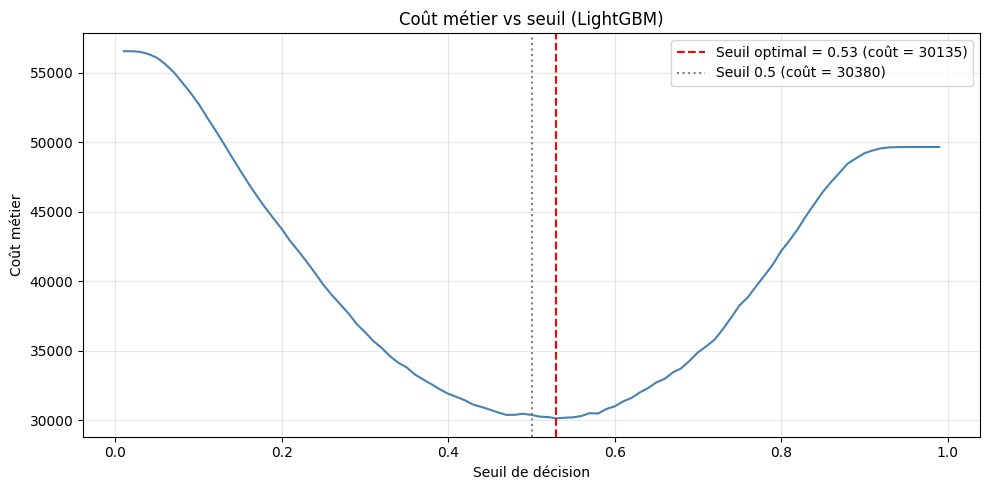

In [9]:
# Courbe coût vs seuil
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, costs, color='steelblue')
ax.axvline(optimal_threshold, color='red', linestyle='--', 
           label=f'Seuil optimal = {optimal_threshold:.2f} (coût = {optimal_cost:.0f})')
ax.axvline(0.5, color='gray', linestyle=':', label=f'Seuil 0.5 (coût = {default_cost:.0f})')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Coût métier')
ax.set_title(f'Coût métier vs seuil ({best_model_name})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Sauvegarde + log MLflow
fig_path = FIGURES_DIR / 'threshold_optimization.png'
fig.savefig(fig_path, dpi=100, bbox_inches='tight')
plt.show()

## 7. Évaluation finale (seuil 0.5 vs seuil optimal)

On quantifie le gain apporté par l'optimisation du seuil sur toutes les métriques.

In [10]:
def all_metrics(y_true, y_pred, y_proba):
    return {
        'auc': roc_auc_score(y_true, y_proba),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'business_cost': business_cost(y_true, y_pred),
    }

y_pred_default = (y_proba >= 0.5).astype(int)
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

comparison = pd.DataFrame({
    'Seuil 0.5': all_metrics(y_test, y_pred_default, y_proba),
    f'Seuil optimal ({optimal_threshold:.2f})': all_metrics(y_test, y_pred_optimal, y_proba),
}).round(4)
print("Comparaison des métriques :")
print(comparison)

Comparaison des métriques :
                Seuil 0.5  Seuil optimal (0.53)
auc                0.7852                0.7852
accuracy           0.7251                0.7532
precision          0.1837                0.1964
recall             0.6985                0.6653
f1                 0.2909                0.3033
business_cost  30380.0000            30135.0000


## 8. Sensibilité du seuil à la fonction de coût

Le seuil optimal qu'on a trouvé (≈ 0.53) suppose un ratio FN/FP = 10. Mais ce ratio est une hypothèse métier qui peut évoluer (changement des taux d'intérêt, nouvelle stratégie commerciale, etc.). On regarde ici comment le seuil optimal change si on modifie ce ratio.

Trois scénarios :
- Ratio 5 : politique plus tolérante (un FN coûte 5× plus qu'un FP)
- Ratio 10 : notre référence
- Ratio 20 : politique très stricte (un FN coûte 20× plus qu'un FP)

Ratio 5: seuil optimal = 0.68
Ratio 10: seuil optimal = 0.53
Ratio 20: seuil optimal = 0.36


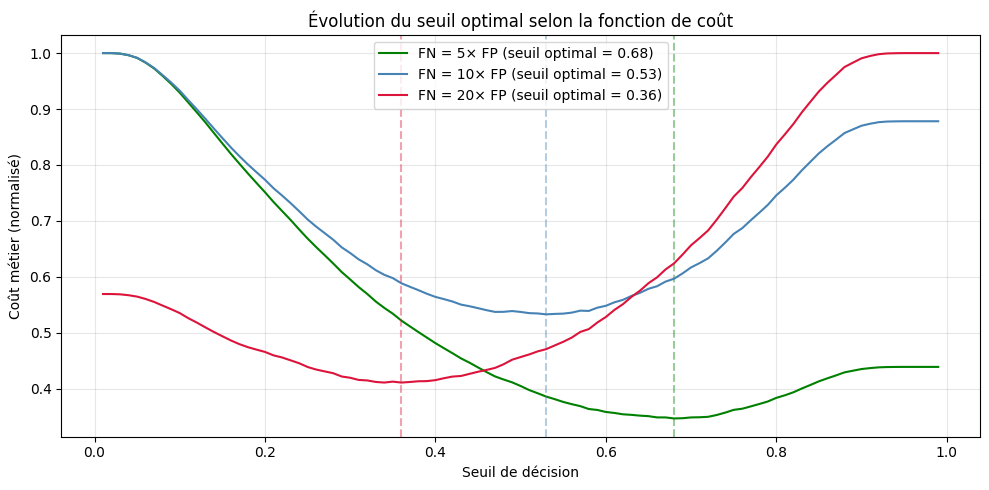

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

ratios = [5, 10, 20]
colors = ['green', 'steelblue', 'crimson']

for ratio, color in zip(ratios, colors):
    costs_r = [business_cost(y_test, (y_proba >= thr).astype(int), fn_cost=ratio, fp_cost=1)
               for thr in thresholds]
    costs_r = np.array(costs_r)
    opt_thr = thresholds[costs_r.argmin()]
    # Normalisation pour pouvoir afficher les 3 courbes sur la même échelle
    costs_r_norm = costs_r / costs_r.max()
    ax.plot(thresholds, costs_r_norm, color=color, label=f'FN = {ratio}× FP (seuil optimal = {opt_thr:.2f})')
    ax.axvline(opt_thr, color=color, linestyle='--', alpha=0.4)
    print(f"Ratio {ratio}: seuil optimal = {opt_thr:.2f}")

ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Coût métier (normalisé)')
ax.set_title('Évolution du seuil optimal selon la fonction de coût')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = FIGURES_DIR / 'threshold_sensitivity.png'
fig.savefig(fig_path, dpi=100, bbox_inches='tight')
plt.show()

**Lecture** : plus on considère que rater un mauvais client (FN) coûte cher (ratio élevé), plus le modèle doit être strict, le seuil descend pour refuser plus de demandes. À ratio 20, le seuil tombe à 0.35 (refus dès 35% de probabilité de défaut). À ratio 5, on peut se permettre d'être plus laxiste et accepter jusqu'à 0.68 de probabilité.

**Ce que démontre cette analyse - l'argument métier central** :

Le seuil de décision est un **levier d'adaptation à la politique de risque**, indépendant du modèle entraîné. Recalibrer le seuil prend une seconde,  réentraîner le modèle prendrait une journée. Si demain Prêt à dépenser décide d'être plus strict ou plus tolérant (changement de stratégie commerciale, évolution du marché, nouveaux taux d'intérêt), on ajuste juste le seuil.

## 9. Feature importance globale

On regarde quelles features ont contribué le plus aux décisions du modèle final (LightGBM optimisé). Cette info est essentielle pour un chargé d'études qui veut comprendre ce qui pousse le modèle à refuser ou accepter un client.

In [12]:
# Récupération du modèle LightGBM dans le pipeline
lgbm = best_model.named_steps['model']
feature_names = X_train.columns

# Récupération des importances et tri
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': lgbm.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes :")
print(importances.head(20).to_string(index=False))

Top 20 features les plus importantes :
                         feature  importance
                    PAYMENT_RATE         270
                    EXT_SOURCE_1         206
                    EXT_SOURCE_2         169
                    EXT_SOURCE_3         141
                      DAYS_BIRTH         121
                     AMT_ANNUITY         112
       APPROVED_CNT_PAYMENT_MEAN          93
                   DAYS_EMPLOYED          80
                 INSTAL_DPD_MEAN          78
          INSTAL_AMT_PAYMENT_SUM          76
                 AMT_GOODS_PRICE          72
                      AMT_CREDIT          69
                 DAYS_ID_PUBLISH          66
                     CODE_GENDER          60
             ANNUITY_INCOME_PERC          60
          DAYS_LAST_PHONE_CHANGE          53
           PREV_CNT_PAYMENT_MEAN          50
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN          48
   INSTAL_DAYS_ENTRY_PAYMENT_MAX          47
          ACTIVE_DAYS_CREDIT_MAX          47


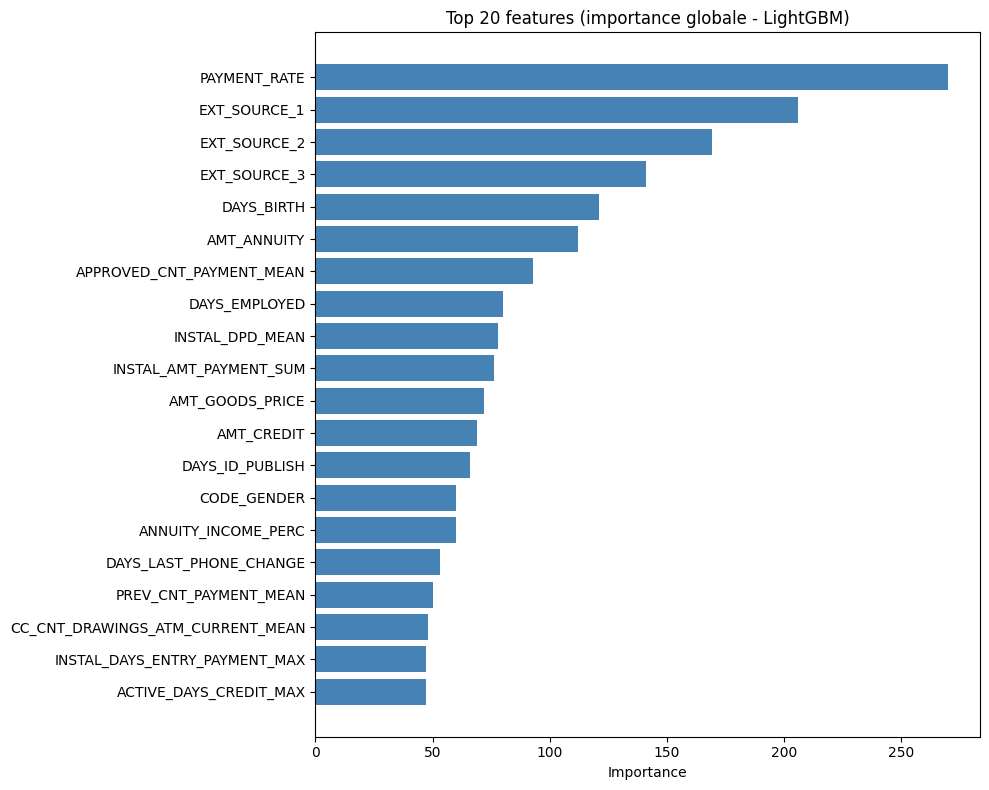

In [13]:
# Visualisation des 20 features les plus importantes
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20).iloc[::-1]  # inversé pour avoir le top en haut du graphique
ax.barh(top20['feature'], top20['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 20 features (importance globale - LightGBM)')
plt.tight_layout()

fig_path = FIGURES_DIR / 'feature_importance_global.png'
fig.savefig(fig_path, dpi=100, bbox_inches='tight')
plt.show()

**Observation :**

- **`PAYMENT_RATE` arrive en tête** : c'est une feature qu'on a **créée nous-mêmes** au notebook 02 (`AMT_ANNUITY / AMT_CREDIT` = poids de l'annuité dans le crédit). Donc le feature engineering apporte du signal au-delà des features brutes.
- Viennent ensuite les trois scores externes dans l'ordre `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`, cohérent avec les corrélations vues à l'EDA (notebook 01).
- Les features dérivées de `installments_payments` (`INSTAL_*`) et les agrégations du Bureau (`ACTIVE_*`, `APPROVED_*`) ressortent aussi, ce qui valide globalement l'apport des tables annexes.

Le modèle s'appuie donc sur trois familles d'informations : les scores externes (fournis), les agrégations historiques (calculées), et les ratios métier (construits).

## 10. Feature importance locale (SHAP)

L'importance globale dit quelles features comptent en moyenne, mais pas pourquoi le modèle a pris **cette** décision pour **ce** client. SHAP répond à ça : pour un client donné, on voit quelles features ont poussé sa probabilité de défaut vers le haut ou vers le bas.

On regarde 3 clients représentatifs :
- Un client classé en défaut avec haute probabilité (le modèle est très sûr)
- Un client classé bon avec haute probabilité
- Un client à la frontière (proche du seuil de décision)

In [14]:
# On applique le pipeline jusqu'à l'imputation (mais pas le modèle final) sur le test set, pour avoir les données dans le format que LightGBM voit réellement
X_test_imputed = best_model.named_steps['imputer'].transform(X_test)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# Création de l'explainer SHAP pour les modèles à arbres (rapide)
explainer = shap.TreeExplainer(lgbm)

# On échantillonne un peu pour gagner du temps (SHAP sur 60k lignes prendrait longtemps)
sample_size = 1000
X_sample = X_test_imputed.sample(n=sample_size, random_state=RANDOM_STATE)
y_proba_sample = best_model.predict_proba(X_test.loc[X_sample.index])[:, 1]

shap_values = explainer.shap_values(X_sample)
print(f"SHAP values calculées pour {sample_size} clients.")

SHAP values calculées pour 1000 clients.


In [15]:
# Sélection des 3 clients représentatifs dans l'échantillon
proba_series = pd.Series(y_proba_sample, index=X_sample.index)

idx_default = proba_series.idxmax()   # client avec la plus haute proba de défaut
idx_good = proba_series.idxmin()       # client avec la plus basse proba de défaut
idx_borderline = (proba_series - optimal_threshold).abs().idxmin()  # le plus proche du seuil

selected = {
    'Défaut très probable': idx_default,
    'Bon client très probable': idx_good,
    'Cas limite (proche du seuil)': idx_borderline,
}

for label, idx in selected.items():
    print(f"{label} : proba = {proba_series.loc[idx]:.3f}")

Défaut très probable : proba = 0.904
Bon client très probable : proba = 0.018
Cas limite (proche du seuil) : proba = 0.530



--- Défaut très probable (proba = 0.904) ---


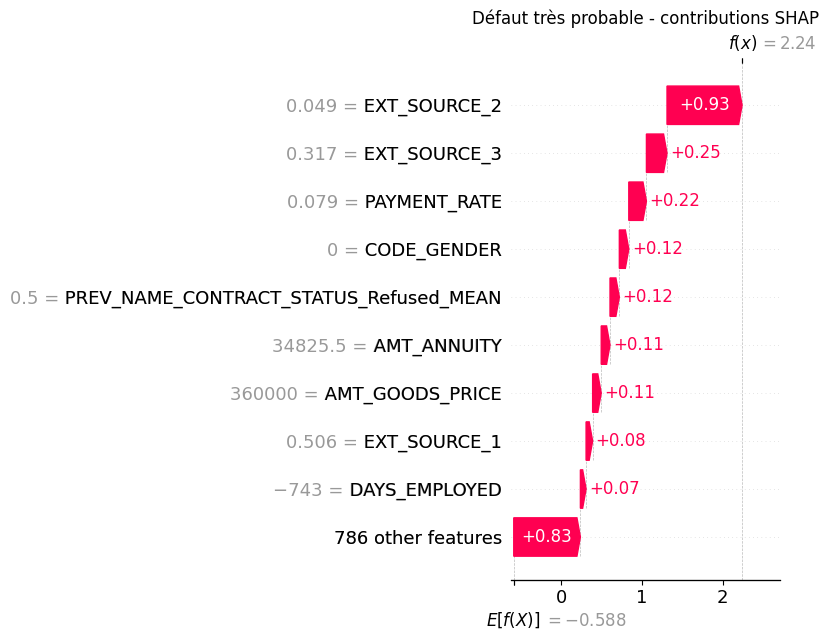


--- Bon client très probable (proba = 0.018) ---


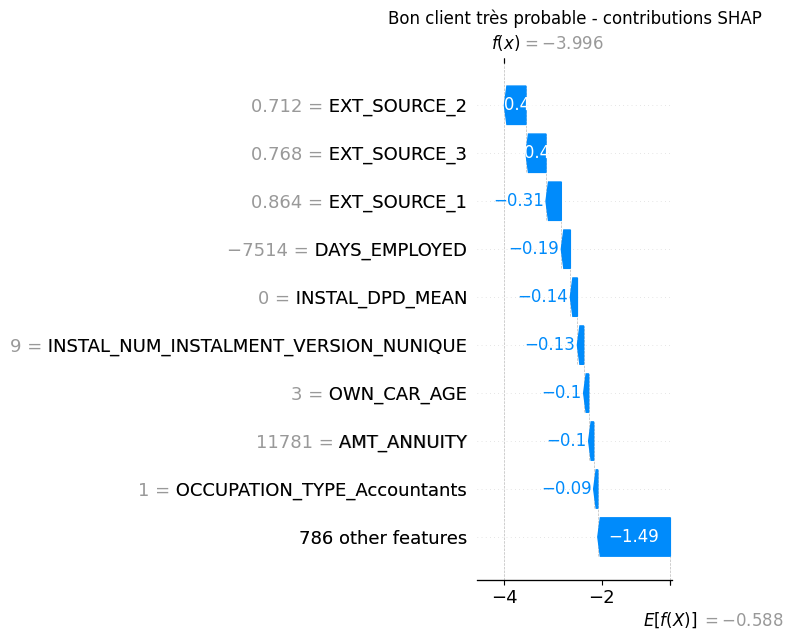


--- Cas limite (proche du seuil) (proba = 0.530) ---


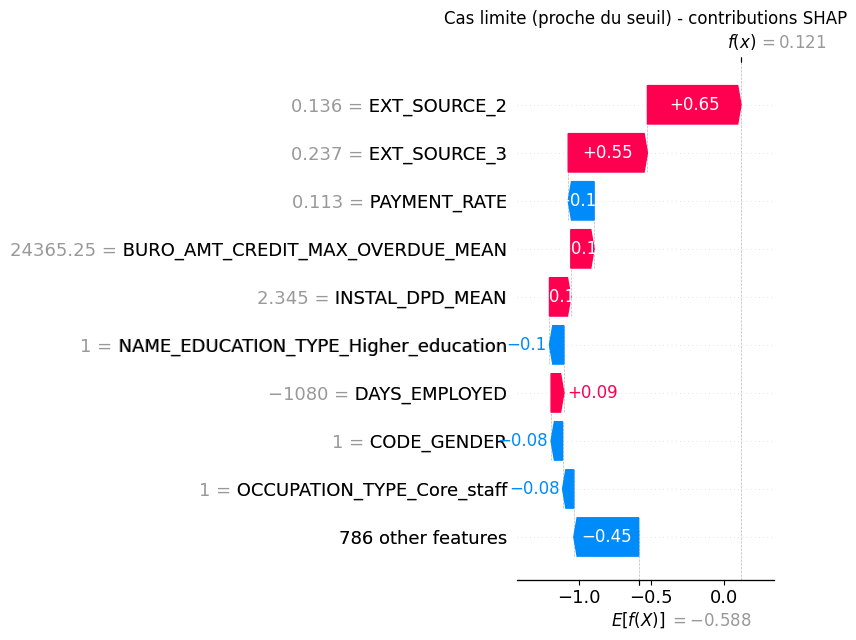

In [16]:
# Pour chaque client, on affiche un waterfall plot SHAP qui montre la contribution de chaque feature à la prédiction
shap_paths = []
for label, idx in selected.items():
    print(f"\n--- {label} (proba = {proba_series.loc[idx]:.3f}) ---")
    position = X_sample.index.get_loc(idx)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[position],
            base_values=explainer.expected_value,
            data=X_sample.iloc[position].values,
            feature_names=X_sample.columns.tolist(),
        ),
        max_display=10,
        show=False,
    )
    plt.title(f'{label} - contributions SHAP')
    plt.tight_layout()
    fig_path = FIGURES_DIR / f'shap_local_{label.replace(" ", "_")}.png'
    plt.savefig(fig_path, dpi=100, bbox_inches='tight')
    shap_paths.append(fig_path)
    plt.show()

**Lecture des graphiques SHAP** : pour chaque client, on voit les 10 features qui ont le plus poussé la décision dans un sens ou dans l'autre.
- **Rouge** = feature qui augmente la probabilité de défaut estimée (pousse vers un refus = risque de FP si bon client)
- **Bleu** = feature qui diminue la probabilité de défaut (pousse vers une acceptation = risque de FN si mauvais client)
- La valeur `f(x)` finale est la prédiction du modèle, à comparer au seuil métier (0.53).

C'est les explications qu'on peut transmettre à un client : *« votre dossier a été refusé principalement à cause de votre score externe EXT_SOURCE_2 et de votre historique d'incidents de paiement »*.

## 11. Enregistrement final dans MLflow et Model Registry

On regroupe en un seul run :
- les hyperparamètres optimaux + le seuil optimal
- les métriques au seuil optimal
- les graphiques (courbe coût/seuil, sensibilité, feature importance, SHAP)
- le modèle sérialisé, enregistré directement dans le **Model Registry** sous le nom `P6_credit_scoring_model`

Le Model Registry centralise les modèles validés et gère leur versioning (alias `production`, `staging`, etc.). C'est l'infrastructure qui permettra le serving via MLflow ou une API REST par la suite.

In [17]:
with mlflow.start_run(run_name='final_model'):
    mlflow.set_tag('phase', 'final')
    mlflow.set_tag('model_family', best_model_name)

    # Hyperparamètres optimaux + seuil
    for k, v in gridsearch_results[best_model_name]['best_params'].items():
        mlflow.log_param(k, v)
    mlflow.log_param('optimal_threshold', optimal_threshold)

    # Métriques au seuil optimal
    for metric_name, value in all_metrics(y_test, y_pred_optimal, y_proba).items():
        mlflow.log_metric(f'final_{metric_name}', value)
    mlflow.log_metric('cost_reduction', default_cost - optimal_cost)

    # Artefacts : tous les graphiques produits dans ce notebook
    mlflow.log_artifact(FIGURES_DIR / 'threshold_optimization.png')
    mlflow.log_artifact(FIGURES_DIR / 'threshold_sensitivity.png')
    mlflow.log_artifact(FIGURES_DIR / 'feature_importance_global.png')
    for shap_path in shap_paths:
        mlflow.log_artifact(shap_path)

    # Modèle sérialisé + enregistrement direct dans le Model Registry
    model_info = mlflow.sklearn.log_model(
        sk_model=best_model,
        name='model',
        registered_model_name='P6_credit_scoring_model',
    )
    print(f"Modèle final enregistré dans le registry : P6_credit_scoring_model")
    print(f"URI : {model_info.model_uri}")

# Transition de la dernière version vers l'alias 'production'
client = MlflowClient()
latest_version = client.get_latest_versions('P6_credit_scoring_model')[0]
client.set_registered_model_alias(
    name='P6_credit_scoring_model',
    alias='production',
    version=latest_version.version,
)
print(f"Version {latest_version.version} taguée comme 'production'.")

2026/05/16 18:46:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/16 18:46:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Modèle final enregistré dans le registry : P6_credit_scoring_model
URI : models:/m-ca2912e833f940ffa22f166375689cfd
Version 1 taguée comme 'production'.


Successfully registered model 'P6_credit_scoring_model'.
Created version '1' of model 'P6_credit_scoring_model'.


Le modèle est maintenant accessible depuis l'UI MLflow → onglet **Models** → `P6_credit_scoring_model` → alias `production`. Il peut être chargé n'importe où via :

```python
import mlflow
model = mlflow.sklearn.load_model('models:/P6_credit_scoring_model@production')
```

## 12. Synthèse

**Modèle retenu :** LightGBM optimisé

**Hyperparamètres optimaux** (issus du GridSearchCV sur le coût métier) :
- `learning_rate=0.05`
- `n_estimators=200`
- `num_leaves=31`
- `min_child_samples=20`
- `scale_pos_weight=11.39` (ratio classe majoritaire / classe minoritaire)

**Seuil métier optimal :** 0.53 (vs 0.5 par défaut)

**Performance finale au seuil optimal (sur le test set, 61 502 clients) :**
- AUC : 0.7852
- Recall (classe défaut) : 0.66
- Precision : 0.20
- F1 : 0.30
- **Coût métier : 30 200** (vs 30 277 au seuil 0.5)

**Lecture du coût** : sur ~5 000 défauts dans le test set, le modèle en détecte ~3 300 (recall 0.66). Sur les ~56 500 bons clients, il en refuse à tort ~10 800 (precision 0.20).

**Réflexion sur la gestion du déséquilibre** : avec `scale_pos_weight=11.39`, le rééquilibrage des classes est déjà fait au niveau de l'apprentissage. À ratio FN/FP = 10, l'optimisation du seuil n'apporte qu'un gain marginal (0.3 %). En revanche, la **section 8 (sensibilité)** montre que le seuil reste un levier important : il permet d'adapter le modèle à n'importe quelle politique métier (ratio 5 → seuil 0.68 ; ratio 20 → seuil 0.35) **sans réentraîner**. C'est un gain pour la flexibilité métier.

**Tout est tracké dans MLflow** (experiment `P6_optimization`, modèle dans le registry `P6_credit_scoring_model` avec alias `production`).